In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files

uploaded = files.upload()

Saving heart.csv to heart.csv


In [3]:
df = pd.read_csv('heart.csv')

In [4]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [5]:
df.shape

(303, 14)

In [6]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [8]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [9]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [10]:
df.duplicated().sum()

np.int64(1)

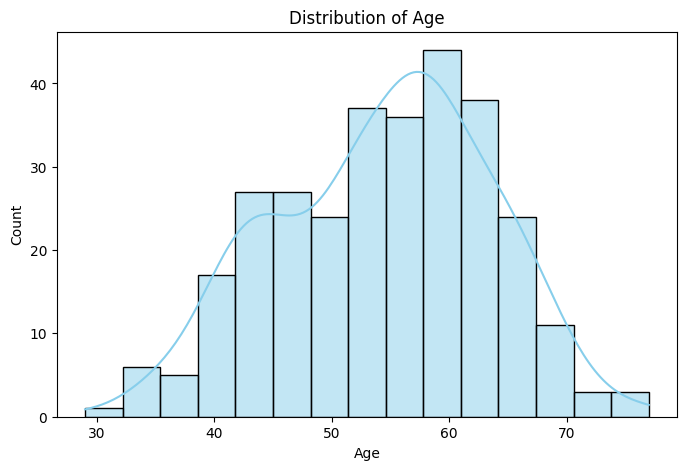

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=15, kde=True, color='skyblue')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

### Insight:
Most patients in the dataset are between 50 and 60 years of age. The age distribution is concentrated around the middle-age group.

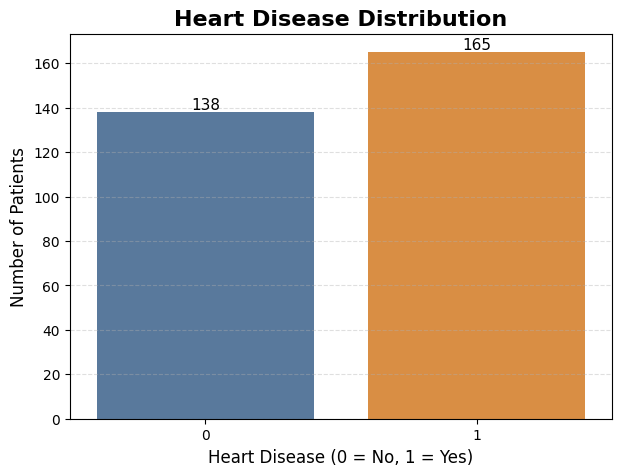

In [23]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    x='target',
    data=df,
    hue='target',
    palette=['#4E79A7', '#F28E2B'],
    legend=False
)

plt.title('Heart Disease Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Heart Disease (0 = No, 1 = Yes)', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)

for container in ax.containers:
    ax.bar_label(container, fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

### Insight:
The dataset contains both patients with and without heart disease. Slightly more patients have heart disease than those without it.

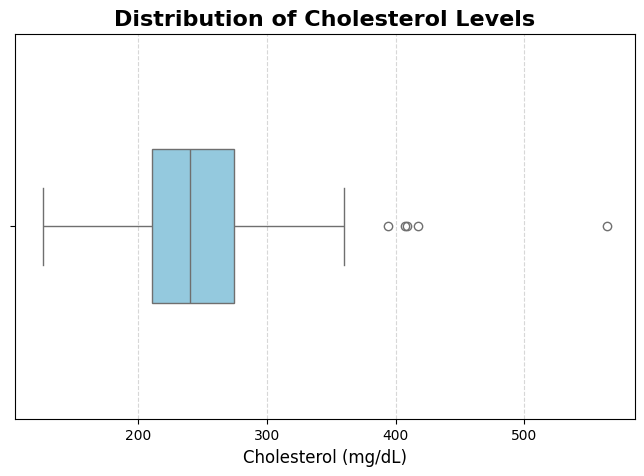

In [18]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='chol',
    data=df,
    color='skyblue',
    width=0.4
)

plt.title('Distribution of Cholesterol Levels', fontsize=16, fontweight='bold')
plt.xlabel('Cholesterol (mg/dL)', fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.show()

### Insight:
The cholesterol column contains some outliers. These unusually high cholesterol values may require further investigation.

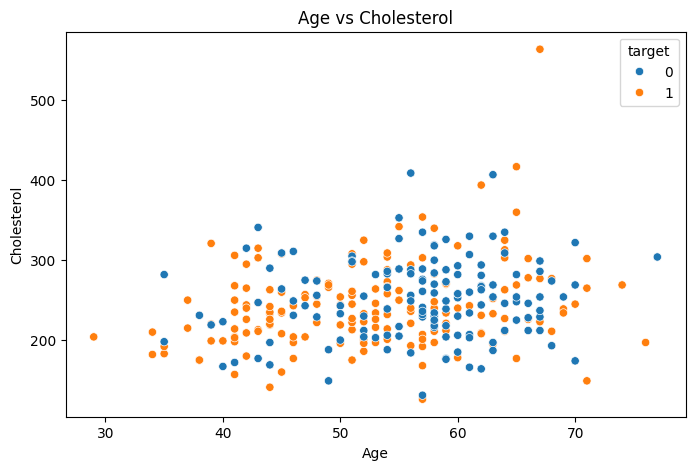

In [19]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='age', y='chol', data=df, hue='target')
plt.title('Age vs Cholesterol')
plt.xlabel('Age')
plt.ylabel('Cholesterol')
plt.show()

### Insight:
There is no strong relationship between age and cholesterol levels. Patients with and without heart disease are spread across different age groups.

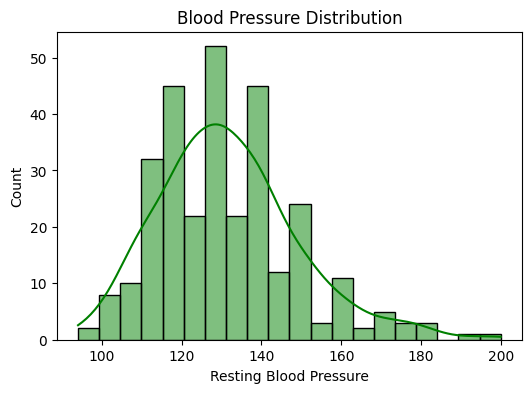

In [24]:
plt.figure(figsize=(6,4))
sns.histplot(df['trestbps'], bins=20, kde=True, color='green')
plt.title("Blood Pressure Distribution")
plt.xlabel("Resting Blood Pressure")
plt.ylabel("Count")
plt.show()

### Insight:
Most patients have resting blood pressure between 120 and 140 mmHg, with the highest concentration around 130 mmHg. A few patients have unusually high blood pressure (above 170 mmHg), indicating possible outliers.

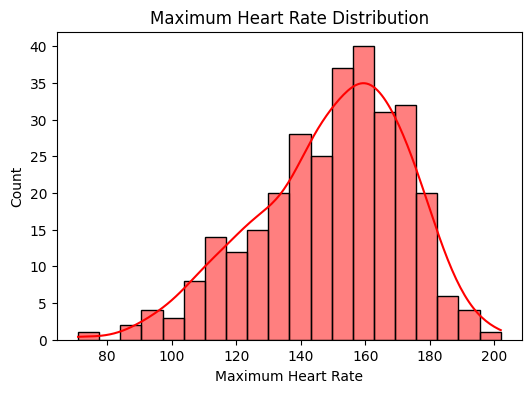

In [26]:
plt.figure(figsize=(6,4))
sns.histplot(df['thalach'], bins=20, kde=True, color='red')
plt.title("Maximum Heart Rate Distribution")
plt.xlabel("Maximum Heart Rate")
plt.ylabel("Count")
plt.show()

### Insight:
Most patients have a maximum heart rate between 140 and 170 bpm. Only a few patients have very low or very high heart rate values, indicating that the majority fall within a moderate range.

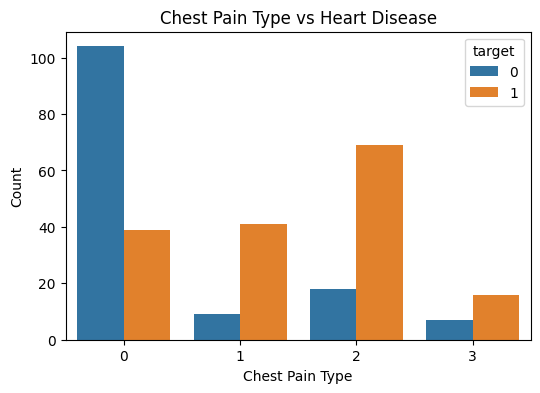

In [27]:
plt.figure(figsize=(6,4))
sns.countplot(x='cp', hue='target', data=df)
plt.title("Chest Pain Type vs Heart Disease")
plt.xlabel("Chest Pain Type")
plt.ylabel("Count")
plt.show()

### Insight:
The occurrence of heart disease varies across different chest pain types. Some chest pain categories have a higher number of patients with heart disease, indicating that chest pain type is an important factor associated with heart disease.

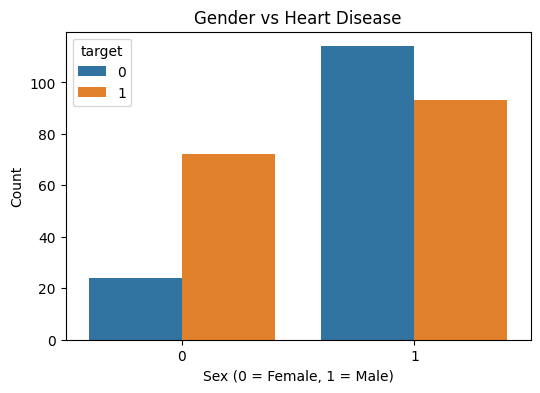

In [28]:
plt.figure(figsize=(6,4))
sns.countplot(x='sex', hue='target', data=df)
plt.title("Gender vs Heart Disease")
plt.xlabel("Sex (0 = Female, 1 = Male)")
plt.ylabel("Count")
plt.show()

### Insight:
The chart shows that heart disease is more common among male patients than female patients. This suggests that gender may be associated with the occurrence of heart disease in this dataset.

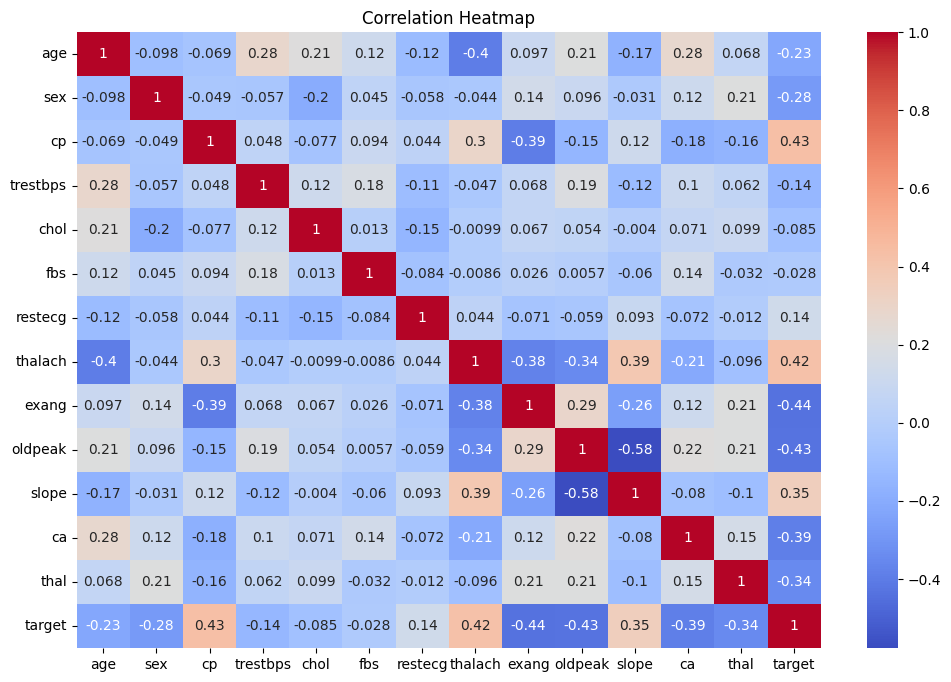

In [29]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### Insight:
The correlation heatmap shows the relationships between all numerical features in the dataset. Chest pain type (cp) and maximum heart rate (thalach) have a positive relationship with heart disease, while exercise-induced angina (exang) and oldpeak show negative relationships. Most other features have weak to moderate correlations, indicating that no single feature alone strongly predicts heart disease.

# Conclusion

The Exploratory Data Analysis (EDA) of the Heart Disease dataset provided valuable insights into the factors associated with heart disease. Most patients were between 50 and 60 years of age, and males had a higher number of heart disease cases than females. Resting blood pressure and maximum heart rate showed clear distributions, while cholesterol contained a few outliers. Chest pain type appeared to be associated with heart disease, and the correlation heatmap highlighted relationships among different medical features. Overall, the analysis helped in understanding the dataset and identifying important patterns that could support further predictive analysis.